# 03 - Models and rankings under the microscope

[UFC_Pipeline](../UFC_Pipeline.ipynb) trains the models, scores them on the test period, ranks the fighters and tests the rankings on real fights. This notebook reads what it saved in `data/processed/` and looks behind the headline numbers:

**Models**
1. Model selection on the validation period
2. Are the probabilities calibrated?
3. Confidence and accuracy
4. What the logistic regression learned
5. The model against the market

**Rankings**
6. Do the rankings predict the fights?
7. Comparison with the official UFC rankings
8. Where the model and Elo disagree
9. Tuning the Elo rating
10. Elo through history

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from ufc_rating import plotting
from ufc_rating.config import (
    ELO_HISTORY_CSV, MASTER_CSV, MODELS_PKL, PREDICTIONS_CSV, RANKING_BACKTEST_CSV, RANKINGS_CSV,
    WIKI_RANKINGS_CSV,
)
from ufc_rating.models.training import format_scores, load_models
from ufc_rating.processing.master import american_to_prob, read_master, read_official_rankings
from ufc_rating.ranking.backtest import backtest_summary, format_summary
from ufc_rating.ranking.elo import CLOSE_DECISION_WEIGHT, K_FACTOR, compute_elo, peak_elo
from ufc_rating.ranking.rankings import compare_with_official, latest_official_ranks, method_agreement

plotting.setup()
bundle = load_models(MODELS_PKL)
results = bundle['results']
best = results['best_stats_model']
predictions = pd.read_csv(PREDICTIONS_CSV, parse_dates=['date'])
rankings = pd.read_csv(RANKINGS_CSV)
elo_history = pd.read_csv(ELO_HISTORY_CSV, parse_dates=['date'])
master = read_master(MASTER_CSV)
picks = pd.read_csv(RANKING_BACKTEST_CSV, parse_dates=['date'])

## 1. Model selection on the validation period

The hyperparameters of each model were tuned by time-ordered cross-validation inside the training period. The validation period, which none of the models was fitted on, then picks the stats model used for the round-robin rankings (lowest log loss). After this choice, every model is refitted on training + validation before being scored on the test period.

In [2]:
print(f'Selected for the rankings: {best}')
format_scores(results['validation'])

Selected for the rankings: LogReg


,Fights,Accuracy,AUC,Log loss,Brier
LogReg,978,61.0%,0.672,0.645,0.227
SVM,978,61.5%,0.669,0.646,0.228
RandomForest,978,60.0%,0.657,0.655,0.232
XGBoost,978,60.9%,0.659,0.653,0.231
Elo only,978,56.4%,0.594,0.681,0.244


The four models land close to each other. The linear models (logistic regression, linear SVM) are at least as good as the tree ensembles: with a few thousand fights and features that are already differences between the two fighters, there is little non-linear structure left for the trees to find.

## 2. Are the probabilities calibrated?

For a rating system the probability matters more than the pick: a "60%" should win 60% of the time. Test-period predictions are grouped by predicted probability and compared with the observed win rate.

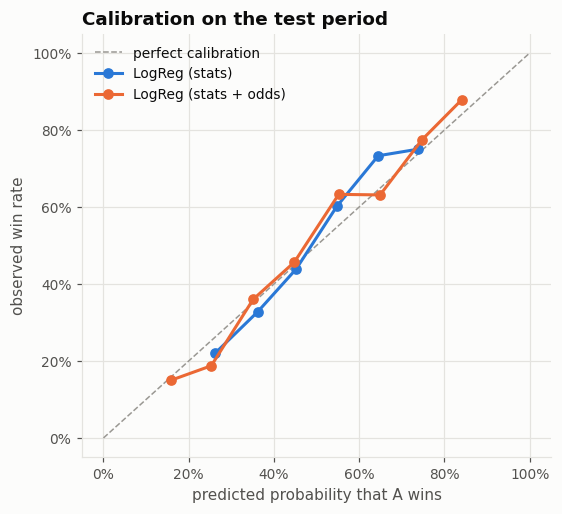

In [3]:
y = predictions['a_wins']
series = {f'{best} (stats)': predictions[f'{best} (stats)'],
          f'{best} (stats + odds)': predictions[f'{best} (stats + odds)']}

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], color=plotting.NEUTRAL, linewidth=1, linestyle='--', label='perfect calibration')
for (name, proba), color in zip(series.items(), plotting.SERIES):
    bins = pd.cut(proba, np.linspace(0, 1, 11))
    table = pd.DataFrame({'p': proba, 'y': y}).groupby(bins, observed=True).agg(p=('p', 'mean'), y=('y', 'mean'), n=('y', 'size'))
    table = table[table['n'] >= 20]
    ax.plot(table['p'], table['y'], marker='o', color=color, label=name)
ax.set_xlabel('predicted probability that A wins')
ax.set_ylabel('observed win rate')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Calibration on the test period')
ax.legend(loc='upper left')
plt.show()

Both models rank fights in the right order, but the stats-only model is **underconfident**: when it gives a fighter 55% or 65%, that fighter actually wins about 60% or 73% of the time. The strong regularisation chosen by cross-validation on the older fights pulls its probabilities towards 50%, and recent fights turn out to be more predictable than older ones. The odds give the second model the confidence to single out clear favourites, and it stays closer to the diagonal.

Underconfidence does not change which fighter is favoured, so accuracy, AUC and the round-robin order are unaffected; it does cost some log loss. Recalibrating on the validation period would be the next step.

## 3. Confidence and accuracy

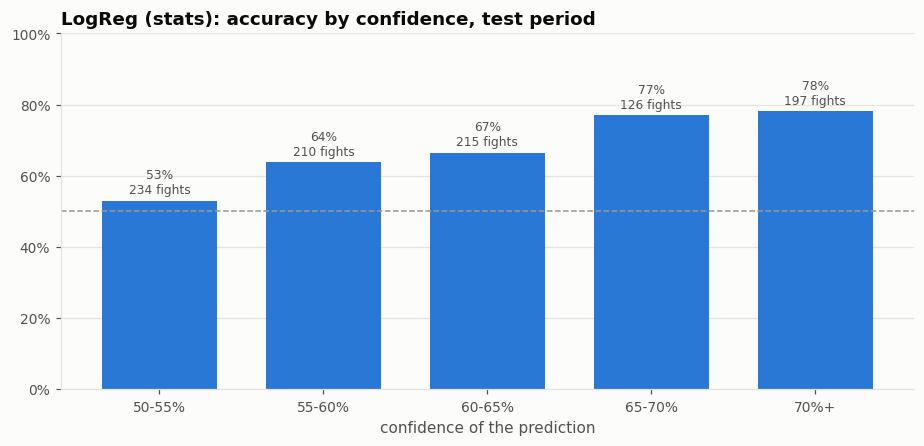

In [4]:
proba = predictions[f'{best} (stats)']
confidence = np.maximum(proba, 1 - proba)
correct = (proba > 0.5) == (y == 1)
buckets = pd.cut(confidence, [0.5, 0.55, 0.6, 0.65, 0.7, 1.0], include_lowest=True,
                 labels=['50-55%', '55-60%', '60-65%', '65-70%', '70%+'])
by_confidence = pd.DataFrame({'correct': correct, 'bucket': buckets}).groupby('bucket', observed=False)['correct'].agg(['mean', 'size'])

ax = by_confidence['mean'].plot.bar(color=plotting.BLUE, width=0.7)
ax.axhline(0.5, color=plotting.NEUTRAL, linewidth=1, linestyle='--')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 1)
ax.set_title(f'{best} (stats): accuracy by confidence, test period')
ax.set_xlabel('confidence of the prediction')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='x', visible=False)
for x, (acc, n) in enumerate(by_confidence.itertuples(index=False)):
    ax.text(x, acc + 0.02, f'{acc:.0%}\n{n} fights', ha='center', fontsize=8, color=plotting.INK_SECONDARY)
plt.show()

Accuracy rises with confidence, as it should. A large share of fights sits in the 50-60% band where the model honestly does not know: UFC matchmaking pairs fighters of similar level on purpose.

## 4. What the logistic regression learned

The features are scaled to unit variance, so each coefficient is the change in log-odds of winning for a one-standard-deviation advantage over the opponent.

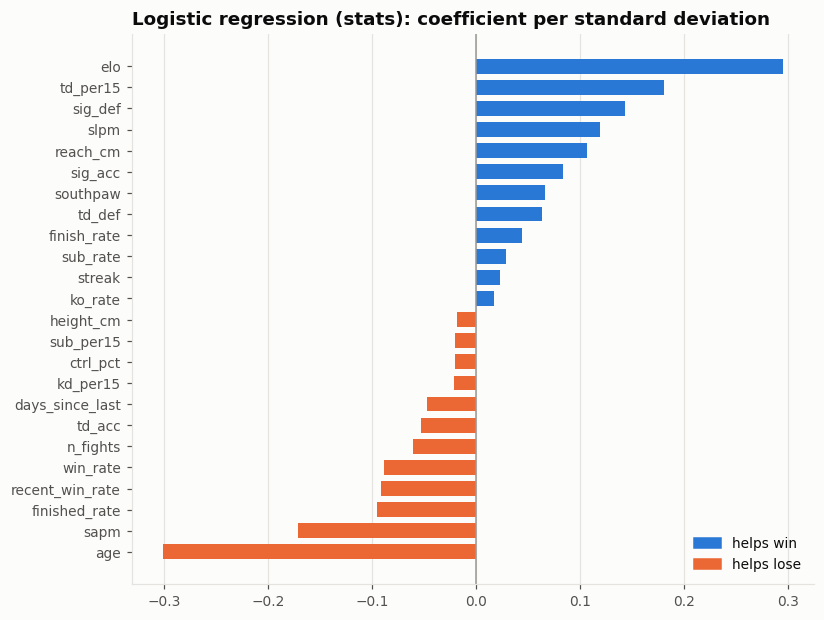

In [5]:
logreg = bundle['stats']['LogReg'].named_steps['model']
coefs = pd.Series(logreg.coef_[0], index=[f.removeprefix('delta_') for f in bundle['stats_features']]).sort_values()

colors = [plotting.BLUE if c > 0 else plotting.ORANGE for c in coefs]
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(coefs.index, coefs.values, color=colors, height=0.7)
ax.axvline(0, color=plotting.NEUTRAL, linewidth=1)
ax.set_title('Logistic regression (stats): coefficient per standard deviation')
ax.grid(axis='y', visible=False)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (plotting.BLUE, plotting.ORANGE)]
ax.legend(handles, ['helps win', 'helps lose'], loc='lower right')
plt.show()

- The largest weights go to **Elo** and **age** (the younger fighter), then **takedown volume**, **strikes absorbed** (fewer is better), striking defence and output, and **reach**: the same signals as in the single-feature analysis of [02_feature_engineering](02_feature_engineering.ipynb).
- The raw win rate and recent form get *negative* weights. This does not mean that winning is bad: Elo and the streak already summarise the record, and among strongly correlated features the regression only keeps a small correction on the extra ones. Coefficients of correlated features have to be read together.
- The strong L2 regularisation chosen by cross-validation keeps every coefficient small. Since the model has no intercept and only differences as inputs, it has no notion of corner or card position.

## 5. The model against the market

On the test fights with odds: how often does the stats model pick the same winner as the bookmakers, and when they disagree, who is right?

In [6]:
market = predictions.dropna(subset=['a_odds_prob'])
model_pick = market[f'{best} (stats)'] > 0.5
market_pick = market['a_odds_prob'] > 0.5
a_won = market['a_wins'] == 1
agree = model_pick == market_pick

summary = pd.DataFrame({
    'fights': [agree.sum(), (~agree).sum()],
    'model right': [(model_pick == a_won)[agree].mean(), (model_pick == a_won)[~agree].mean()],
    'market right': [(market_pick == a_won)[agree].mean(), (market_pick == a_won)[~agree].mean()],
}, index=['model and market agree', 'they disagree'])
summary[['model right', 'market right']] = summary[['model right', 'market right']].map('{:.1%}'.format)
summary

,fights,model right,market right
model and market agree,725,72.8%,72.8%
they disagree,186,41.4%,58.6%


The two agree on most fights. When they disagree, the market is right more often than the model: its extra information (injuries, short-notice replacements, weight cuts, stylistic match-ups) is exactly what public fight statistics cannot see.

## 6. Do the rankings predict the fights?

A ranking claims that a fighter is better than those below; the fights between two ranked fighters test that claim. [UFC_Pipeline](../UFC_Pipeline.ipynb) replays the test period event by event: the day before each event, our rankings are rebuilt from the fights known at that date, with the stats model trained before the test period. In every fight between two fighters who both hold an official rank in the division, each ranking designates the better-ranked fighter as favourite: the official UFC rankings with the ranks published before the fight, the betting market with the closing odds.

The comparison uses the fights where our rankings also rank both fighters (at least five UFC fights and a fight in the last two years).

In [7]:
covered = picks[picks['covered']]
print(f"{len(picks)} fights between two officially ranked fighters in the test period, "
      f"{len(covered)} with both fighters in our rankings")
format_summary(backtest_summary(picks))

246 fights between two officially ranked fighters in the test period, 194 with both fighters in our rankings


,Fights,Favourite won,Picks a different fighter than the official rankings,... and is right,p-value
Official rankings,194,53.4%,,,
Model,194,72.2%,93,65,< 0.001
Elo,194,57.7%,73,41,0.349
Betting favourite,184,71.7%,78,57,< 0.001


- The **official rankings** designate the winner in 53.4% of these fights, barely more than a coin flip.
- The **model ranking** does so in 72.2%, level with the **betting favourite** (71.7%, on the 184 fights with odds).
- **Elo** (57.7%) stays close to the official rankings, in its order (section 7) as in its weakness.

With 194 fights, each share is known to within about 6 to 7 points: enough to separate the model from the official rankings, not to separate it from the market.

**Is the difference real?** On most fights the rankings agree, so they are compared on the fights where they designate different favourites. If the two rankings were equally good, each would be right on about half of these fights; the p-value (two-sided sign test) is the chance of a split at least as uneven as the one observed.

**Are we flattering ourselves by leaving fights out?** The fights left out are those where our rankings do not rank one of the fighters in that division: too new to the UFC (fewer than five fights), just moved from another division, or back from a layoff of more than two years. The official rankings do not do better on them:

In [8]:
picks.groupby(picks['covered'].map({True: 'in our rankings', False: 'left out'}))[
    ['Official rankings', 'Betting favourite']].agg(['mean', 'count']).round(3)

Official rankings       Betting favourite      
                             mean count              mean count
covered                                                        
in our rankings             0.534   194             0.717   184
left out                    0.519    52             0.620    50

### Over a longer period

The official rankings exist since 2013. Over every fight between two ranked fighters since then, their favourite is compared with the fighter with the higher pre-fight Elo, with the younger fighter (a naive rule that knows nothing about the record) and with the betting favourite. No model is involved, so the whole period can be used.

In [9]:
before = elo_history.set_index(['fight_id', 'fighter_id'])['elo_before']
ranked = master[(master['date'] >= '2013-02-01') & master['outcome'].isin(['r', 'b'])
                & master['r_rank'].notna() & master['b_rank'].notna()].copy()
r_won = (ranked['outcome'] == 'r').to_numpy()

def favourite_won(r_value, b_value, lower_is_better=False):
    """1 if the favourite won, 0 if it lost, 0.5 on a tie, NaN without a value."""
    r_value, b_value = np.asarray(r_value, dtype=float), np.asarray(b_value, dtype=float)
    r_favoured = b_value - r_value if lower_is_better else r_value - b_value
    return np.where(np.isnan(r_favoured), np.nan, np.where(r_favoured == 0, 0.5, (r_favoured > 0) == r_won))

def elo_of(side):
    return before.reindex(pd.MultiIndex.from_arrays([ranked['fight_id'], ranked[f'{side}_id']])).to_numpy()

def birth_day(side):   # later birth = younger fighter
    return (ranked[f'{side}_dob'] - pd.Timestamp('1900-01-01')).dt.days

long_run = pd.DataFrame({
    'Official rankings': favourite_won(ranked['r_rank'], ranked['b_rank'], lower_is_better=True),
    'Higher Elo': favourite_won(elo_of('r'), elo_of('b')),
    'Younger fighter': favourite_won(birth_day('r'), birth_day('b')),
    'Betting favourite': favourite_won(american_to_prob(ranked['r_odds']), american_to_prob(ranked['b_odds'])),
}, index=ranked.index)
period = pd.cut(ranked['date'].dt.year, [2012, 2017, 2021, 2026], labels=['2013-2017', '2018-2021', '2022-2026'])
table = long_run.groupby(period, observed=True).mean()
table.loc['all'] = long_run.mean()
table['fights'] = list(period.value_counts(sort=False)) + [len(ranked)]
table.style.format({c: '{:.1%}' for c in long_run.columns})

,Official rankings,Higher Elo,Younger fighter,Betting favourite,fights
date,,,,,
2013-2017,64.1%,58.2%,56.3%,63.7%,428
2018-2021,54.6%,55.1%,59.5%,59.1%,432
2022-2026,51.4%,54.2%,60.5%,67.5%,489
all,56.5%,55.7%,58.9%,63.6%,1349


Over thirteen years and 1,349 fights, the official favourite wins 56.5% of the time. The official rankings did better at first (64% in 2013-2017, level with the market) and have declined since, to about a coin flip in 2022-2026 (51%), while the market stayed between 59% and 68%. Over the whole period they do worse than the naive rule "the younger fighter wins" (58.9%), and the higher Elo does no better (55.7%): a ranking of *records* says little about who wins the next fight between two established fighters.

Does a large gap between the two official ranks mean more?

In [10]:
gap = (ranked['r_rank'] - ranked['b_rank']).abs()
bands = pd.cut(gap, [0, 2, 5, 15], include_lowest=True, labels=['0-2 places', '3-5 places', '6+ places'])
(long_run['Official rankings'].groupby(bands, observed=True).agg(['mean', 'size'])
    .rename(columns={'mean': 'official favourite won', 'size': 'fights'}).round(3))

,official favourite won,fights
0-2 places,0.573,637
3-5 places,0.538,509
6+ places,0.606,203


Barely: the better-ranked fighter wins 57% of the fights between fighters two places apart or less, 54% at three to five places and 61% at six places or more.

The official rankings reward the record: a fighter climbs by beating ranked opponents and stays up until they lose, so the rankings are slow to register both decline and rise. The model looks at what predicts the next fight instead: age, physical attributes, Elo and how the fighter wins and loses. That the younger fighter wins more often than the better-ranked one points the same way.

## 7. Comparison with the official UFC rankings

The latest weekly snapshot of the official rankings (from Wikipedia) is compared with our model and Elo ranks, per division, over the fighters present in both lists (Spearman correlation, 1 = same order). Two official rankings exist since June 2026: the **media panel**, voted by journalists, and the **Meta UFC Rankings**, computed by a rating model built with Meta.

In [11]:
official = read_official_rankings(WIKI_RANKINGS_CSV, master)
comparisons = {}
for system, label in (('media', 'media panel'), ('meta', 'Meta UFC Rankings')):
    latest = latest_official_ranks(official, system)
    comparisons[label] = compare_with_official(rankings, latest)
    print(f"{label}: snapshot of {latest['rank_date'].iloc[0].date()}")
pd.concat(comparisons, axis=1)

media panel: snapshot of 2026-09-22
Meta UFC Rankings: snapshot of 2026-09-22


media panel              \
                     ranked fighters compared Model   Elo   
division                                                    
Flyweight                                  15  0.55  0.73   
Bantamweight                               15  0.49  0.81   
Featherweight                              13  0.63  0.93   
Lightweight                                14  0.49  0.83   
Welterweight                               14  0.85  0.84   
Middleweight                               16  0.41  0.91   
Light Heavyweight                          15  0.41  0.57   
Heavyweight                                11  0.89  0.92   
Women's Strawweight                        13  0.69  0.98   
Women's Flyweight                          15  0.64  0.96   
Women's Bantamweight                       12  0.27  0.81   

                            Meta UFC Rankings              
                     ranked fighters compared Model   Elo  
division                                                   
Flyweight                                  13  0.58  0.80  
Bantamweight                               15  0.59  0.87  
Featherweight                              13  0.50  0.93  
Lightweight                                14  0.35  0.80  
Welterweight                               14  0.85  0.82  
Middleweight                               16  0.53  0.95  
Light Heavyweight                          14  0.31  0.50  
Heavyweight                                12  0.88  0.94  
Women's Strawweight                        13  0.58  0.87  
Women's Flyweight                          15  0.34  0.92  
Women's Bantamweight                       11  0.50  0.45

In [12]:
pd.concat({label: table[['Model', 'Elo']].mean() for label, table in comparisons.items()}, axis=1).round(2).rename_axis('mean over divisions')

,media panel,Meta UFC Rankings
mean over divisions,,
Model,0.57,0.55
Elo,0.84,0.80


Elo is by far the closer to both official rankings: mean correlation 0.84 with the media panel and 0.80 with the Meta UFC Rankings, against 0.57 and 0.55 for the model, and the closer in every division except welterweight (both lists) and women's bantamweight (Meta). That is expected: the panel ranks fighters by *who they beat*, the Meta UFC Rankings are themselves a rating model that weighs the quality of the opponents, and Elo is built on the results against rated opponents alone.

Section 6 puts this in perspective: being close to the official order is not the same as predicting fights. Elo shares the weakness of the official rankings, and the model, the furthest from the official lists, is the one that designates the winners.

## 8. Where the model and Elo disagree

Spearman correlation between the model and Elo ranks per division, then, among each division's current top 10, the fighters whose two ranks are furthest apart.

In [13]:
method_agreement(rankings)

,fighters,Model vs Elo
division,,
Flyweight,35,0.91
Bantamweight,53,0.80
Featherweight,56,0.78
Lightweight,77,0.82
Welterweight,65,0.85
Middleweight,56,0.88
Light Heavyweight,34,0.72
Heavyweight,33,0.86
Women's Strawweight,37,0.84


In [14]:
top = rankings[rankings['rank'] <= 10].copy()
top['gap'] = (top['Model rank'] - top['Elo rank']).abs()
(top.sort_values('gap', ascending=False)
    .head(10)[['division', 'Fighter', 'UFC record', 'Model', 'Elo', 'Model rank', 'Elo rank']]
    .reset_index(drop=True))

,division,Fighter,UFC record,Model,Elo,Model rank,Elo rank
0,Light Heavyweight,Oumar Sy,3-3,0.648,1496,5,27
1,Lightweight,Fares Ziam,8-4,0.683,1599,9,29
2,Welterweight,Myktybek Orolbai,5-2,0.737,1635,7,27
3,Women's Strawweight,Julia Polastri,3-3,0.593,1506,10,25
4,Bantamweight,Raul Rosas Jr.,6-1,0.767,1659,3,17
5,Middleweight,Bo Nickal,6-1,0.742,1664,4,15
6,Featherweight,Youssef Zalal,8-4-1,0.725,1676,4,14
7,Women's Flyweight,Carli Judice,4-1,0.701,1619,4,13
8,Middleweight,Ateba Gautier,5-0,0.713,1654,8,17
9,Welterweight,Max Holloway,24-9,0.683,1889,10,2


The model and Elo agree broadly (correlation between 0.72 and 0.91 depending on the division) and disagree in two typical ways:

- **Prospects.** Few UFC fights, a young age and strong statistics put Raul Rosas Jr. (6-1), Bo Nickal (6-1) or Ateba Gautier (5-0) in the model's top 10, while their Elo, built on few fights, is still far below the veterans'. The model also ranks a few fighters with an even record high on the strength of their profile (Oumar Sy, 3-3, 5th at light heavyweight): these are its boldest calls.
- **Veterans.** A long record against strong opponents gives Max Holloway the second Elo of the welterweight division, while his age pulls his model score down (10th).

## 9. Tuning the Elo rating

Two settings define the Elo rating: **K**, how many points a single fight can move (the textbook value for chess is 32), and how much a **split or majority decision** counts, since the judges themselves disagreed on the winner. They were chosen on the fights from 2005 up to the start of the test period, by the log loss of Elo-only predictions (the pre-fight ratings turned into a win probability). The grid below reruns that choice.

In [15]:
test_start = predictions['date'].min()
scored = master[master['outcome'].isin(['r', 'b']) & (master['date'] >= '2005-01-01') & (master['date'] < test_start)]
r_won = (scored['outcome'] == 'r').to_numpy()

def elo_log_loss(k, close_weight):
    before = compute_elo(master, k=k, close_weight=close_weight).set_index(['fight_id', 'fighter_id'])['elo_before']
    r = before.reindex(pd.MultiIndex.from_arrays([scored['fight_id'], scored['r_id']])).to_numpy()
    b = before.reindex(pd.MultiIndex.from_arrays([scored['fight_id'], scored['b_id']])).to_numpy()
    p_r = 1 / (1 + 10 ** ((b - r) / 400))
    return -np.mean(np.log(np.where(r_won, p_r, 1 - p_r)))

grid = pd.DataFrame({weight: {k: elo_log_loss(k, weight) for k in (32, 48, 64, 80, 96, 128)}
                     for weight in (1.0, 0.5, 0.25)})
grid.index.name = 'K'
grid.columns.name = 'weight of a split / majority decision'
print(f'{len(scored):,} fights scored. Chosen: K = {K_FACTOR:.0f}, close decisions weighted {CLOSE_DECISION_WEIGHT}.')
grid.round(4)

7,109 fights scored. Chosen: K = 80, close decisions weighted 0.5.


weight of a split / majority decision,1.00,0.50,0.25
K,,,
32,0.6839,0.6830,0.6827
48,0.6818,0.6804,0.6800
64,0.6807,0.6788,0.6783
80,0.6804,0.6781,0.6776
96,0.6809,0.6782,0.6777
128,0.6842,0.6805,0.6801


Two findings:

- **K should be much larger than in chess.** A UFC fighter has a few fights a year and a career of a few dozen at most, so the rating has to move fast to follow them. The log loss is lowest between K = 64 and 96 and rises again beyond.
- **Close decisions should count less, at every K.** Halving the weight of split and majority decisions improves the fit whatever the value of K.

The best cell of the grid (K = 80 with a weight of 0.25) is barely better than the chosen one (K = 80, weight 0.5), a difference too small to matter; half a win is the more natural value and the one kept. Against the textbook K = 32 with every win counted the same, the chosen setting improves the Elo-only log loss by about 0.006, far more than any of the feature groups tested in [02_feature_engineering](02_feature_engineering.ipynb).

## 10. Elo through history

In [16]:
peak_elo(elo_history, top=15)

,Fighter,Peak Elo,Reached on
1,Jon Jones,2055,2024-11-16
2,Islam Makhachev,2051,2026-08-15
3,Kamaru Usman,2006,2021-11-06
4,Georges St-Pierre,1988,2017-11-04
5,Merab Dvalishvili,1954,2025-10-04
6,Leon Edwards,1950,2023-12-16
7,Alexander Volkanovski,1947,2022-07-02
8,Anderson Silva,1947,2012-10-13
9,Belal Muhammad,1940,2024-07-27
10,Khabib Nurmagomedov,1935,2020-10-24


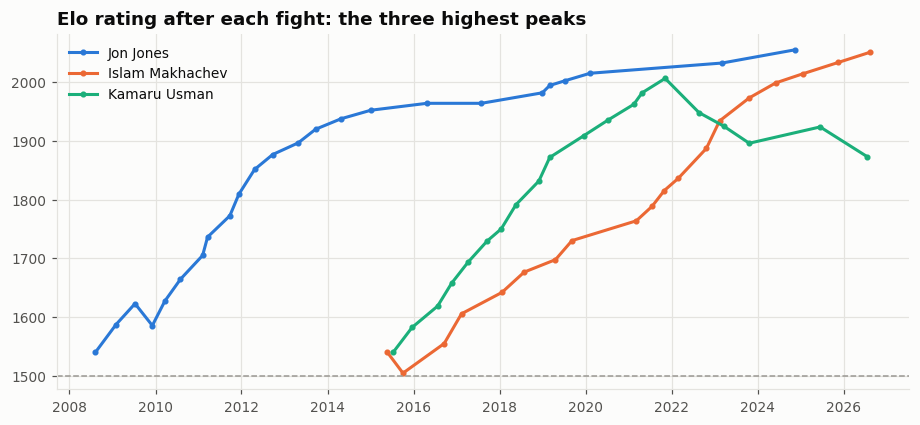

In [17]:
legends = list(peak_elo(elo_history, top=3)['Fighter'])
fig, ax = plt.subplots()
for name, color in zip(legends, plotting.SERIES):
    career = elo_history[elo_history['fighter_name'] == name].sort_values('date')
    ax.plot(career['date'], career['elo_after'], marker='o', markersize=3, color=color, label=name)
ax.axhline(1500, color=plotting.NEUTRAL, linewidth=1, linestyle='--')
ax.set_title('Elo rating after each fight: the three highest peaks')
ax.set_xlabel('')
ax.legend(loc='upper left')
plt.show()

Elo climbs with every win and drops after a loss, more sharply when the loss is an upset (Jones's 2009 disqualification, Makhachev's 2015 knockout); a no contest leaves it unchanged. The highest peaks come from long winning runs against rated opposition, so the length of a career matters: Khabib Nurmagomedov, unbeaten in 13 UFC fights, peaks lower (10th) than fighters who won for longer.